In [2]:
pip install osmnx

Note: you may need to restart the kernel to use updated packages.


In [10]:
import osmnx as ox

Matplotlib is building the font cache; this may take a moment.


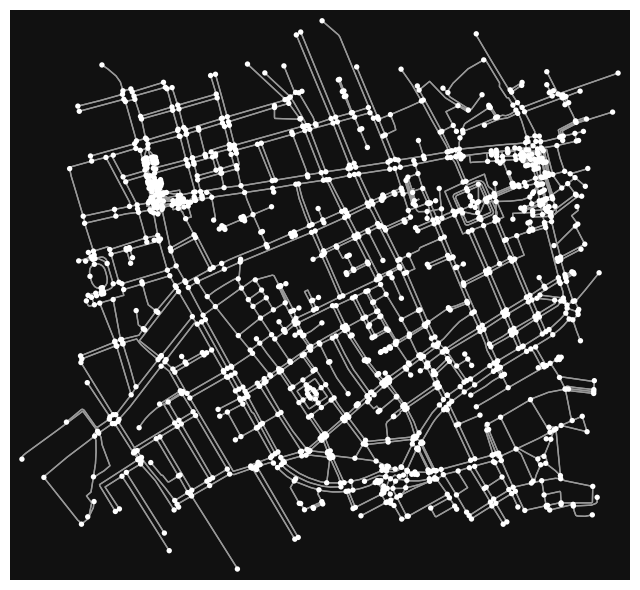

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [2]:
import osmnx as ox

north, south, east, west = 51.5155, 51.5115, -0.1310, -0.1420
buffer = 0.002
bbox = (west - buffer, south - buffer, east + buffer, north + buffer)

G = ox.graph_from_bbox(bbox, network_type="walk", truncate_by_edge=True)
ox.plot_graph(G)

In [3]:
# 方式A:按地名直接抓取(最简单,但要确认边界准确)
G = ox.graph_from_place("Soho, City of Westminster, London, UK", network_type="walk")


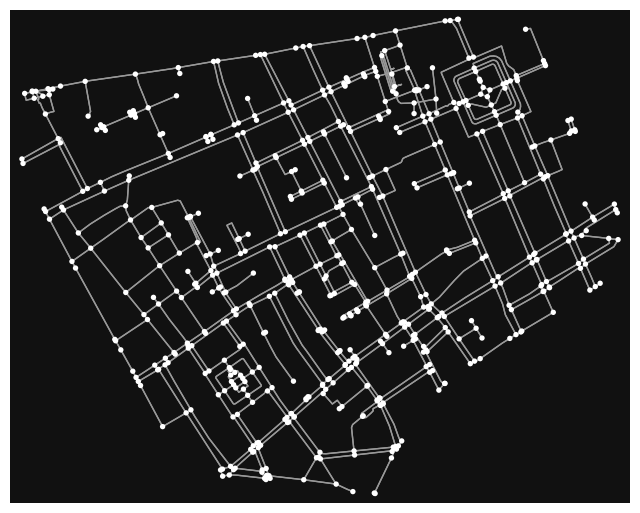

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [4]:

# 保存为图结构,方便后续在Mesa里调用
ox.save_graphml(G, filepath="soho_walk_network.graphml")

# 可视化检查一下抓取范围对不对
ox.plot_graph(G)

In [6]:
import osmnx as ox
import networkx as nx

# osmnx的统计功能
print(ox.stats.basic_stats(G))

# networkx检查连通性(用无向图)
G_undirected = G.to_undirected()
print(nx.is_connected(G_undirected))

{'n': 599, 'm': 1600, 'k_avg': 5.342237061769616, 'edge_length_total': 42345.399464439426, 'edge_length_avg': 26.46587466527464, 'streets_per_node_avg': 2.7829716193656093, 'streets_per_node_counts': {0: 0, 1: 139, 2: 0, 3: 314, 4: 144, 5: 2}, 'streets_per_node_proportions': {0: 0.0, 1: 0.23205342237061768, 2: 0.0, 3: 0.5242070116861436, 4: 0.24040066777963273, 5: 0.00333889816360601}, 'intersection_count': 460, 'street_length_total': 21172.699732219662, 'street_segment_count': 800, 'street_length_avg': 26.465874665274576, 'circuity_avg': 1.0316418792356052, 'self_loop_proportion': 0.0}
True


In [7]:
ox.save_graphml(G, filepath="soho_walk_network.graphml")

In [9]:
bbox = (west, south, east, north)  # 注意顺序:left, bottom, right, top

G_bike = ox.graph_from_bbox(bbox, network_type="bike")
G_drive = ox.graph_from_bbox(bbox, network_type="drive")

buildings = ox.features_from_bbox(bbox, tags={"building": True})

In [4]:
nodes = ox.graph_to_gdfs(G, edges=False)
minx, miny, maxx, maxy = nodes.total_bounds

In [5]:
print(f"Bounding box: {minx}, {miny}, {maxx}, {maxy}")

Bounding box: -0.1415564, 51.5102453, -0.1295152, 51.5162063


In [1]:
pip install osmnx geopandas shapely networkx pandas mesa pyproj


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import osmnx as ox
G = ox.graph_from_point((51.5137, -0.1315), dist=300, network_type="bike")
print(G.number_of_nodes())  # 能打印出数字就说明联网OK

193


In [4]:
import sys
sys.path.insert(0, "/Users/wusiyi/Documents/CASA/dis/DATA/files")

from environment import load_soho_center_latlon
lat, lon = load_soho_center_latlon("/Users/wusiyi/Documents/CASA/dis/DATA")
print(lat, lon)

51.51350000000001 -0.1365


In [5]:
import requests
import pandas as pd

lat, lon = 51.51350000000001, -0.1365  # 换成你实际算出来的圆心
headers = {"x-api-version": "2"}
url = "http://api.ratings.food.gov.uk/Establishments"

rows = []
page = 1
while True:
    params = {
        "latitude": lat,
        "longitude": lon,
        "maxDistanceLimit": 3,       # 英里，覆盖最大候选半径 + 余量
        "pageNumber": page,
        "pageSize": 5000,
    }
    r = requests.get(url, headers=headers, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()
    est = data.get("establishments", [])
    if not est:
        break
    rows.extend(est)
    if len(est) < 5000:
        break
    page += 1

df = pd.DataFrame(rows)
df["lon"] = df["geocode"].apply(lambda g: g.get("longitude") if isinstance(g, dict) else None)
df["lat"] = df["geocode"].apply(lambda g: g.get("latitude") if isinstance(g, dict) else None)
df["BusinessType"] = df["BusinessType"]  # FSA原始字段名就是这个，一般不用改
df = df.dropna(subset=["lon", "lat"])
df.to_csv("/Users/wusiyi/Documents/CASA/dis/DATA/soho_food_pois_wide.csv", index=False)
print(len(df), "条 POI")

16528 条 POI


In [7]:
import osmnx as ox

G = ox.load_graphml("/Users/wusiyi/Documents/CASA/dis/DATA/raw/soho_bike_network_r1900.graphml")
lengths = [d.get("length", 0) for _, _, d in G.edges(data=True)]
lengths = [float(l) for l in lengths if l]

print(f"路段数：{len(lengths)}")
print(f"平均路段长度：{sum(lengths)/len(lengths):.1f} 米")
print(f"中位数路段长度：{sorted(lengths)[len(lengths)//2]:.1f} 米")

# 顺便算一下节点密度，另一个可以佐证"密路网"的指标
area_km2 = 3.14159 * (1.9 ** 2)  # 半径1900m对应的圆形面积，约11.34平方公里
print(f"节点密度：{G.number_of_nodes() / area_km2:.1f} 个/平方公里")

路段数：11210
平均路段长度：45.6 米
中位数路段长度：34.1 米
节点密度：468.5 个/平方公里


In [1]:
import pandas as pd
df = pd.read_csv("/Users/wusiyi/Documents/CASA/dis/DATA/soho_food_pois_r1900.csv")
print(df["BusinessType"].value_counts())

BusinessType
Restaurant/Cafe/Canteen                  3230
Retailers - other                         850
Takeaway/sandwich shop                    333
Pub/bar/nightclub                         228
Hotel/bed & breakfast/guest house         183
Other catering premises                   151
Retailers - supermarkets/hypermarkets      60
School/college/university                  50
Importers/Exporters                        39
Caring Premises                            27
Manufacturers/packers                      22
Mobile caterer                             18
Distributors/Transporters                  11
Name: count, dtype: int64
